<a href="https://colab.research.google.com/github/Rihabd06/portfolio-site/blob/main/Handwritten_Numbers_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report

In [ ]:
# Loading MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data() # Keras provides MNIST via tf.keras.datasets.mnist

print("Raw shapes:", x_train.shape, y_train.shape, x_test.shape, y_test.shape)

Raw shapes: (60000, 28, 28) (60000,) (10000, 28, 28) (10000,)


In [ ]:
# Preprocessing
# Normalize pixel values to [0,1], add channel dim, one-hot labels
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32")  / 255.0

# Add channel dimension (MNIST is grayscale)
x_train = np.expand_dims(x_train, -1)  # shape -> (N, 28, 28, 1)
x_test  = np.expand_dims(x_test, -1)

num_classes = 10
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat  = to_categorical(y_test, num_classes)

print("After preprocess:", x_train.shape, y_train_cat.shape)

After preprocess: (60000, 28, 28, 1) (60000, 10)


In [ ]:
# CNN Model definition
def make_model(input_shape=(28,28,1), num_classes=10):
    model = models.Sequential()
    # First conv block: 32 filters, 3x3 kernel, ReLU activation
    model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=input_shape))
    model.add(layers.MaxPooling2D((2,2)))           # downsample to reduce spatial size
    # Second conv block: 64 filters
    model.add(layers.Conv2D(64, (3,3), activation='relu'))
    model.add(layers.MaxPooling2D((2,2)))
    # Flatten and FC
    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dropout(0.5))                  # reduce overfitting
    model.add(layers.Dense(num_classes, activation='softmax'))
    return model

model = make_model()
model.summary()

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Training
# Use modest epochs (6) for a balance of speed and accuracy.
epochs = 6
batch_size = 128

history = model.fit(x_train, y_train_cat,
                    epochs=epochs,
                    batch_size=batch_size,
                    validation_split=0.1,
                    verbose=2)

Epoch 1/6
422/422 - 38s - 89ms/step - accuracy: 0.9055 - loss: 0.3083 - val_accuracy: 0.9818 - val_loss: 0.0615
Epoch 2/6
422/422 - 36s - 85ms/step - accuracy: 0.9715 - loss: 0.0981 - val_accuracy: 0.9870 - val_loss: 0.0454
Epoch 3/6
422/422 - 39s - 92ms/step - accuracy: 0.9786 - loss: 0.0701 - val_accuracy: 0.9878 - val_loss: 0.0388
Epoch 4/6
422/422 - 35s - 82ms/step - accuracy: 0.9831 - loss: 0.0573 - val_accuracy: 0.9908 - val_loss: 0.0344
Epoch 5/6
422/422 - 36s - 84ms/step - accuracy: 0.9853 - loss: 0.0480 - val_accuracy: 0.9917 - val_loss: 0.0323
Epoch 6/6
422/422 - 35s - 84ms/step - accuracy: 0.9869 - loss: 0.0432 - val_accuracy: 0.9897 - val_loss: 0.0354


In [ ]:
# Evaluate
test_loss, test_acc = model.evaluate(x_test, y_test_cat, verbose=0)
print(f"\nTest loss: {test_loss:.4f}   Test accuracy: {test_acc:.4f}")

# Detailed classification report
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)

print("\nClassification report (precision, recall, f1-score):")
print(classification_report(y_test, y_pred, digits=4))


Test loss: 0.0263   Test accuracy: 0.9916
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step

Classification report (precision, recall, f1-score):
              precision    recall  f1-score   support

           0     0.9919    0.9959    0.9939       980
           1     0.9930    0.9965    0.9947      1135
           2     0.9922    0.9913    0.9918      1032
           3     0.9892    0.9931    0.9911      1010
           4     0.9969    0.9939    0.9954       982
           5     0.9932    0.9877    0.9904       892
           6     0.9917    0.9958    0.9938       958
           7     0.9903    0.9883    0.9893      1028
           8     0.9958    0.9805    0.9881       974
           9     0.9823    0.9921    0.9872      1009

    accuracy                         0.9916     10000
   macro avg     0.9917    0.9915    0.9916     10000
weighted avg     0.9916    0.9916    0.9916     10000



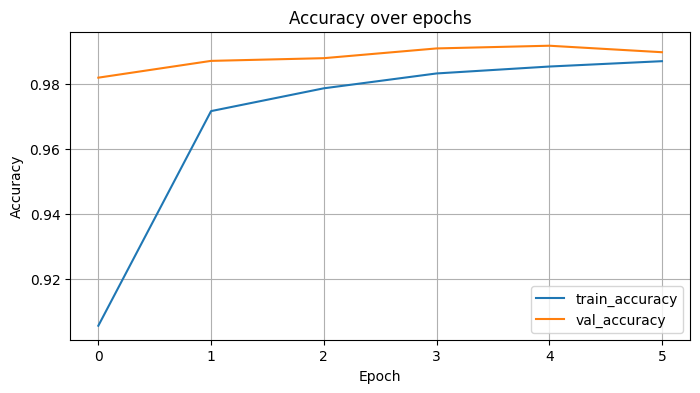

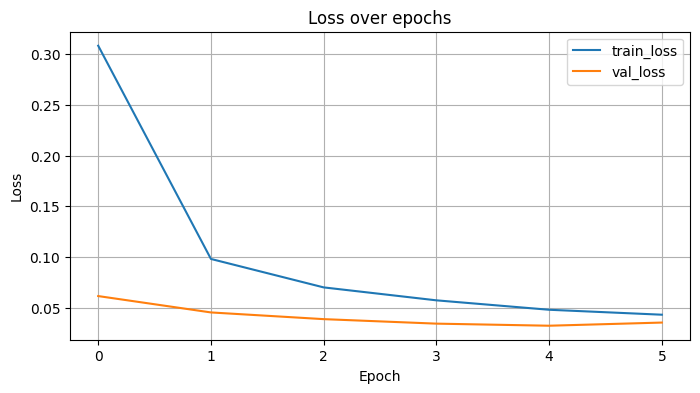

In [ ]:
# Plot training history
plt.figure(figsize=(8,4))
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss over epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

Number of misclassified examples: 84 / 10000


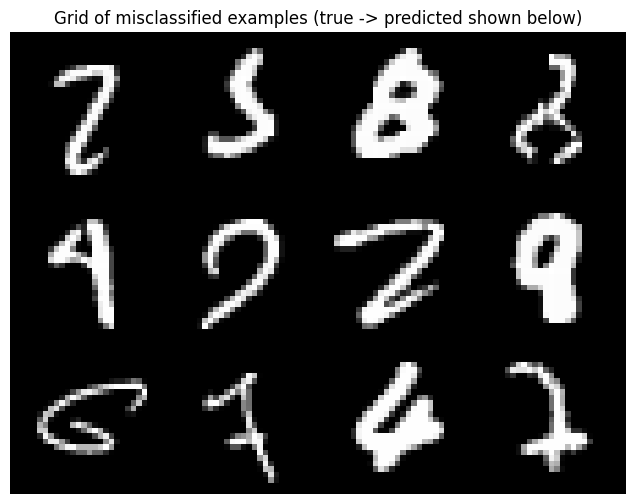


Shown misclassifications (test_index, true -> predicted):
1. test_index=321    2 -> 7
2. test_index=340    5 -> 3
3. test_index=495    8 -> 0
4. test_index=582    8 -> 2
5. test_index=740    4 -> 9
6. test_index=846    7 -> 9
7. test_index=924    2 -> 7
8. test_index=947    8 -> 9
9. test_index=1014    6 -> 5
10. test_index=1039    7 -> 3
11. test_index=1112    4 -> 6
12. test_index=1226    7 -> 2


In [ ]:
# Visualizing misclassifications
mis_idx = np.where(y_pred != y_test)[0]
print(f"Number of misclassified examples: {len(mis_idx)} / {len(y_test)}")

# We'll show up to 12 misclassified examples in a single tiled image
n_show = min(12, len(mis_idx))
if n_show == 0:
    print("No misclassifications found (rare).")
else:
    imgs = []
    for i in range(n_show):
        idx = mis_idx[i]
        img = (x_test[idx].squeeze() * 255).astype(np.uint8)
        imgs.append(img)

    cols = 4
    rows = int(np.ceil(n_show / cols))
    # pad if needed
    empty_img = np.zeros_like(imgs[0])
    while len(imgs) < rows * cols:
        imgs.append(empty_img)

    row_imgs = []
    for r in range(rows):
        row = np.hstack(imgs[r*cols:(r+1)*cols])
        row_imgs.append(row)
    grid_img = np.vstack(row_imgs)

    plt.figure(figsize=(cols*2, rows*2))
    plt.imshow(grid_img, cmap='gray')
    plt.axis('off')
    plt.title('Grid of misclassified examples (true -> predicted shown below)')
    plt.show()

    print("\nShown misclassifications (test_index, true -> predicted):")
    for i in range(n_show):
        idx = mis_idx[i]
        print(f"{i+1}. test_index={idx}    {y_test[idx]} -> {y_pred[idx]}")